# NLP Playground — Tokenization, Stopwords & Word Vectors

**Session 1 companion notebook.** Run each cell top-to-bottom, tweak inputs, and explore.

---

In [1]:
# Install dependencies (run once)
%pip install -q nltk gensim matplotlib scikit-learn numpy

Note: you may need to restart the kernel to use updated packages.


In [2]:
import nltk
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

## 1 — Tokenization

A **token** is the atomic unit of text. Tokenization splits raw text into these units.

In [3]:
from nltk.tokenize import word_tokenize

# --- Try changing this sentence! ---
text = "The cats are sitting on the mats near the river bank."

tokens = word_tokenize(text)
tokens_lower = word_tokenize(text.lower())

print("Original :", text)
print("Tokens   :", tokens)
print("Lowered  :", tokens_lower)
print(f"Count    : {len(tokens_lower)} tokens")

Original : The cats are sitting on the mats near the river bank.
Tokens   : ['The', 'cats', 'are', 'sitting', 'on', 'the', 'mats', 'near', 'the', 'river', 'bank', '.']
Lowered  : ['the', 'cats', 'are', 'sitting', 'on', 'the', 'mats', 'near', 'the', 'river', 'bank', '.']
Count    : 12 tokens


## 2 — Stopwords

**Stop words** are common words (the, is, a, on ...) that carry little meaning on their own. Removing them reduces noise.

In [4]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

print(f"English stop words ({len(stop_words)} total):")
print(sorted(stop_words)[:30], "...\n")

# Clean: keep only alphabetic, non-stopword tokens
clean_tokens = [t for t in tokens_lower if t.isalpha() and t not in stop_words]

print("Before cleaning:", tokens_lower)
print("After cleaning :", clean_tokens)

English stop words (198 total):
['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't"] ...

Before cleaning: ['the', 'cats', 'are', 'sitting', 'on', 'the', 'mats', 'near', 'the', 'river', 'bank', '.']
After cleaning : ['cats', 'sitting', 'mats', 'near', 'river', 'bank']


In [5]:
# Visualize what got removed vs kept
removed = [t for t in tokens_lower if t.isalpha() and t in stop_words]
punctuation = [t for t in tokens_lower if not t.isalpha()]

print("Removed (stop words):", removed)
print("Removed (punctuation):", punctuation)
print("Kept (content words):", clean_tokens)

Removed (stop words): ['the', 'are', 'on', 'the', 'the']
Removed (punctuation): ['.']
Kept (content words): ['cats', 'sitting', 'mats', 'near', 'river', 'bank']


## 3 — Load Pretrained Word Vectors

We'll use **GloVe** vectors (50-dimensional, trained on Wikipedia + Gigaword). First download is ~66 MB, then cached.

In [6]:
import gensim.downloader as api

wv = api.load("glove-wiki-gigaword-50")
print(f"Vocabulary : {len(wv):,} words")
print(f"Dimensions : {wv.vector_size}")

Vocabulary : 400,000 words
Dimensions : 50


In [7]:
# What does a word vector look like?
word = "king" 
vec = wv[word]

print(f"Vector for '{word}' (first 10 dims):")
print(np.round(vec[:10], 3))
print(f"\nFull shape: {vec.shape}")

Vector for 'king' (first 10 dims):
[ 0.505  0.686 -0.595 -0.023  0.6   -0.135 -0.088  0.474 -0.618 -0.31 ]

Full shape: (50,)


## 4 — Similarity & Analogies

In [8]:
# Cosine similarity between word pairs
pairs = [
    ("cat", "dog"),
    ("cat", "kitten"),
    ("coffee", "tea"),
    ("coffee", "car"),
    ("king", "queen"),
    ("king", "democracy"),
]

print("Word Similarity")
print("-" * 40)
for a, b in pairs:
    score = wv.similarity(a, b)
    bar = "█" * int(score * 20) + "░" * (20 - int(score * 20))
    print(f"  {a:12s} ↔ {b:12s}  {bar} {score:.3f}")

Word Similarity
----------------------------------------
  cat          ↔ dog           ██████████████████░░ 0.922
  cat          ↔ kitten        ████████████░░░░░░░░ 0.639
  coffee       ↔ tea           ████████████████░░░░ 0.808
  coffee       ↔ car           ███████░░░░░░░░░░░░░ 0.390
  king         ↔ queen         ███████████████░░░░░ 0.784
  king         ↔ democracy     ██████░░░░░░░░░░░░░░ 0.309


In [9]:
# Nearest neighbors
# --- Try changing the word! ---
query = "coffee"

print(f"Top 10 nearest neighbors of '{query}':\n")
for i, (neighbor, score) in enumerate(wv.most_similar(query, topn=10), 1):
    bar = "█" * int(score * 20) + "░" * (20 - int(score * 20))
    print(f"  {i:2d}. {neighbor:15s} {bar} {score:.3f}")

Top 10 nearest neighbors of 'coffee':

   1. drink           ████████████████░░░░ 0.819
   2. drinks          ████████████████░░░░ 0.818
   3. wine            ████████████████░░░░ 0.814
   4. tea             ████████████████░░░░ 0.808
   5. beer            ████████████████░░░░ 0.804
   6. food            ███████████████░░░░░ 0.785
   7. sugar           ███████████████░░░░░ 0.777
   8. corn            ███████████████░░░░░ 0.761
   9. vegetable       ███████████████░░░░░ 0.760
  10. beverage        ███████████████░░░░░ 0.758


In [10]:
# Vector arithmetic — analogies!
# a - b + c ≈ ?
analogies = [
    ("king",    "man",    "woman"),    # → queen
    ("paris",   "france", "germany"),  # → berlin
    ("bigger",  "big",    "small"),    # → smaller
    ("walking", "walk",   "swim"),     # → swimming
]

print("Analogies:  a - b + c ≈ ?\n")
for a, b, c in analogies:
    results = wv.most_similar(positive=[a, c], negative=[b], topn=1)
    answer, score = results[0]
    print(f"  {a:10s} - {b:10s} + {c:10s} ≈  {answer:10s} ({score:.3f})")

Analogies:  a - b + c ≈ ?

  king       - man        + woman      ≈  queen      (0.852)
  paris      - france     + germany    ≈  berlin     (0.920)
  bigger     - big        + small      ≈  larger     (0.924)
  walking    - walk       + swim       ≈  swimming   (0.807)


In [11]:
# Odd one out
groups = [
    ["cat", "dog", "fish", "car"],
    ["coffee", "tea", "juice", "keyboard"],
    ["france", "germany", "italy", "banana"],
    ["happy", "joyful", "glad", "table"],
]

print("Odd one out:\n")
for group in groups:
    odd = wv.doesnt_match(group)
    labeled = [f"**{w}**" if w == odd else w for w in group]
    print(f"  {group}  →  '{odd}'")

Odd one out:

  ['cat', 'dog', 'fish', 'car']  →  'car'
  ['coffee', 'tea', 'juice', 'keyboard']  →  'keyboard'
  ['france', 'germany', 'italy', 'banana']  →  'banana'
  ['happy', 'joyful', 'glad', 'table']  →  'table'


## 5 — Visualizing Word Vectors (2D)

Word vectors live in 50 dimensions. We use **PCA** to project them down to 2D so we can plot them.
Same idea as squishing a 3D globe onto a flat map — you lose some info but the neighborhoods are preserved.

In [12]:
def plot_words(word_list, wv, title="Word Vectors in 2D", figsize=(10, 7)):
    """Project word vectors to 2D with PCA and plot them."""
    vectors = np.array([wv[w] for w in word_list])
    coords = PCA(n_components=2).fit_transform(vectors)

    fig, ax = plt.subplots(figsize=figsize)
    ax.scatter(coords[:, 0], coords[:, 1], s=60, alpha=0.7)
    for i, word in enumerate(word_list):
        ax.annotate(word, (coords[i, 0], coords[i, 1]),
                    fontsize=12, fontweight="bold",
                    xytext=(5, 5), textcoords="offset points")
    ax.set_title(title, fontsize=14)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel("PC 1")
    ax.set_ylabel("PC 2")
    plt.tight_layout()
    plt.show()

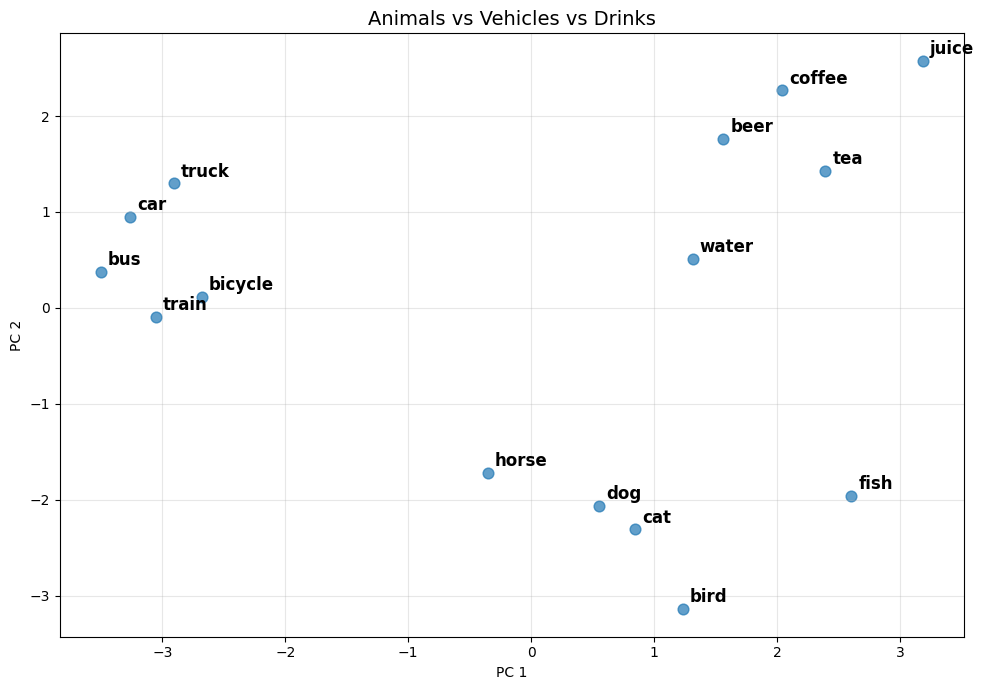

In [13]:
# Animals vs vehicles vs drinks — do they cluster?
words = [
    "cat", "dog", "fish", "horse", "bird",
    "car", "truck", "bus", "bicycle", "train",
    "coffee", "tea", "juice", "water", "beer",
]

plot_words(words, wv, title="Animals vs Vehicles vs Drinks")

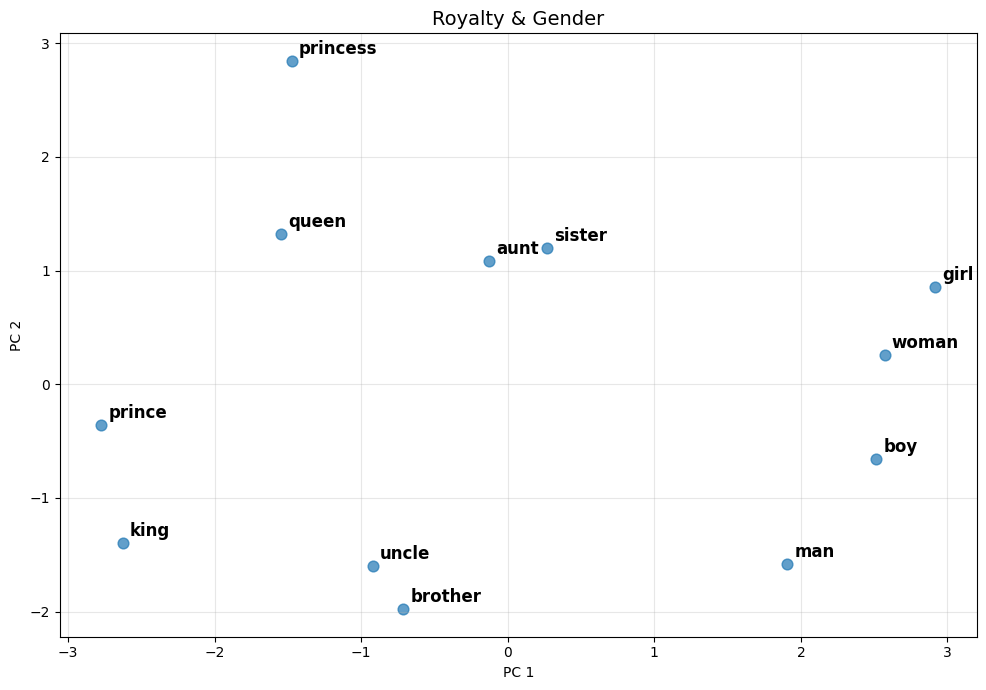

In [14]:
# Royalty & gender — can we see the "gender direction"?
words_royalty = [
    "king", "queen", "prince", "princess",
    "man", "woman", "boy", "girl",
    "uncle", "aunt", "brother", "sister",
]

plot_words(words_royalty, wv, title="Royalty & Gender")

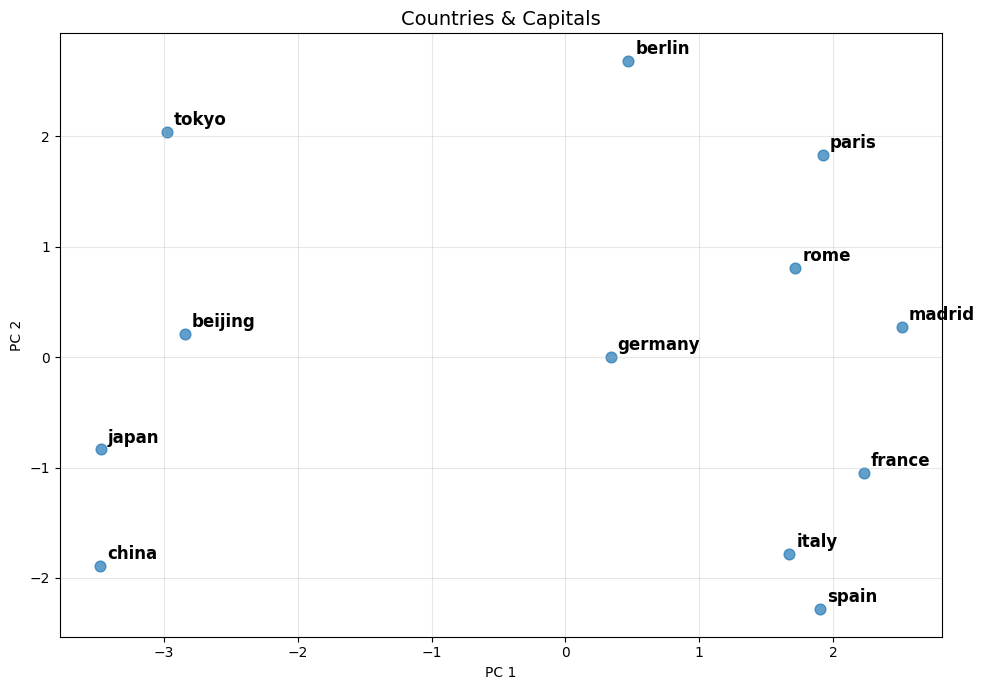

In [15]:
# Countries & capitals
words_geo = [
    "france", "paris", "germany", "berlin",
    "italy", "rome", "spain", "madrid",
    "japan", "tokyo", "china", "beijing",
]

plot_words(words_geo, wv, title="Countries & Capitals")

## 6 — Visualizing Analogy Arithmetic

Let's plot the vector arithmetic `king - man + woman ≈ queen` and see it geometrically.

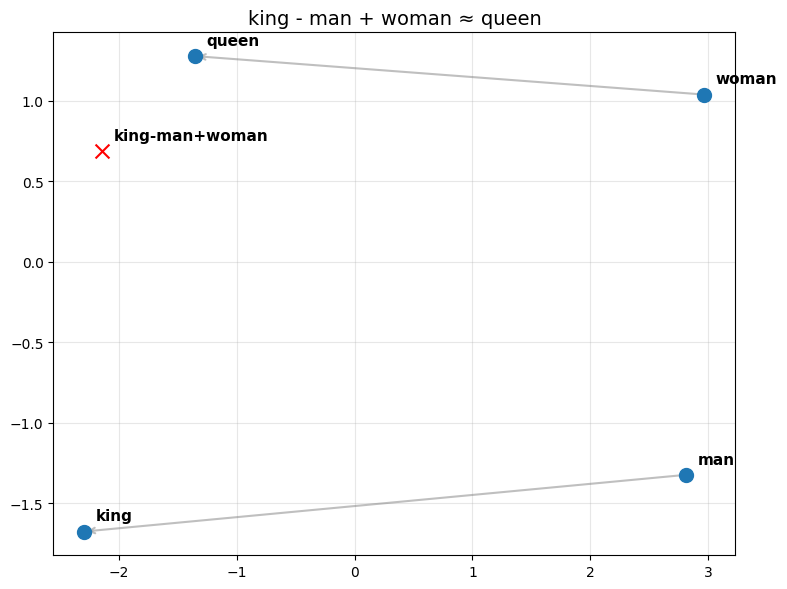

In [16]:
def plot_analogy(a, b, c, wv, figsize=(8, 6)):
    """Visualize a - b + c ≈ ? with arrows."""
    result_vec = wv[a] - wv[b] + wv[c]
    answer = wv.most_similar(positive=[a, c], negative=[b], topn=1)[0][0]

    words = [a, b, c, answer]
    vecs = np.array([wv[w] for w in words] + [result_vec])
    labels = words + [f"{a}-{b}+{c}"]

    coords = PCA(n_components=2).fit_transform(vecs)

    fig, ax = plt.subplots(figsize=figsize)
    # Plot words
    ax.scatter(coords[:4, 0], coords[:4, 1], s=100, zorder=5)
    # Plot computed point
    ax.scatter(coords[4, 0], coords[4, 1], s=100, marker="x", color="red", zorder=5)

    for i, label in enumerate(labels):
        ax.annotate(label, (coords[i, 0], coords[i, 1]),
                    fontsize=11, fontweight="bold",
                    xytext=(8, 8), textcoords="offset points")

    # Draw arrows showing the analogy parallelogram
    style = dict(arrowstyle="->", color="gray", lw=1.5, alpha=0.5)
    ax.annotate("", xy=coords[0], xytext=coords[1],
                arrowprops=style)  # b → a
    ax.annotate("", xy=coords[3], xytext=coords[2],
                arrowprops=style)  # c → answer

    ax.set_title(f"{a} - {b} + {c} ≈ {answer}", fontsize=14)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_analogy("king", "man", "woman", wv)

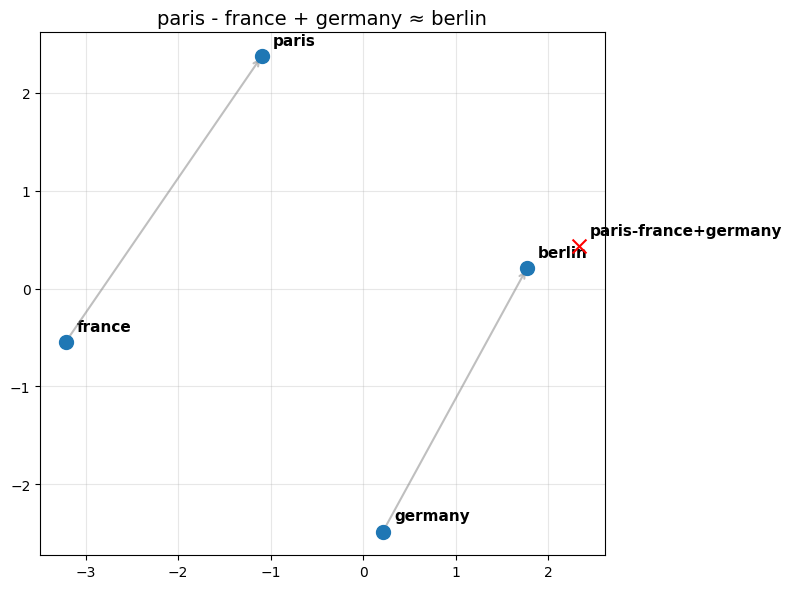

In [17]:
# Try more analogies!
plot_analogy("paris", "france", "germany", wv)

## 7 — Your Turn!

Use the cells below to try your own queries. Change the words and re-run.

In [18]:
# Your similarity query
wv.most_similar("python", topn=10)

[('reticulated', 0.6916366219520569),
 ('spamalot', 0.663573682308197),
 ('php', 0.6414497494697571),
 ('owl', 0.6301496028900146),
 ('mouse', 0.6275478601455688),
 ('reticulatus', 0.6274470686912537),
 ('perl', 0.6267576813697815),
 ('monkey', 0.6207212805747986),
 ('monty', 0.6079354286193848),
 ('scripting', 0.6041733026504517)]

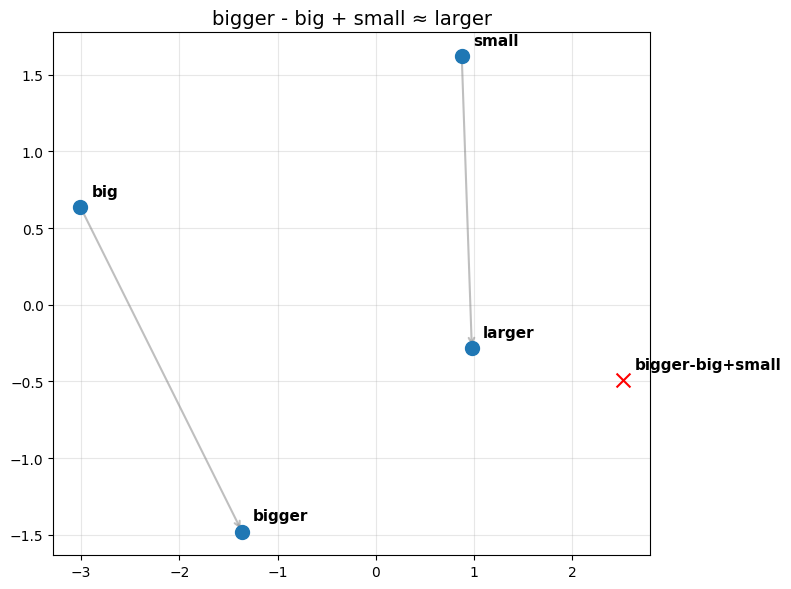

In [19]:
# Your analogy
plot_analogy("bigger", "big", "small", wv)

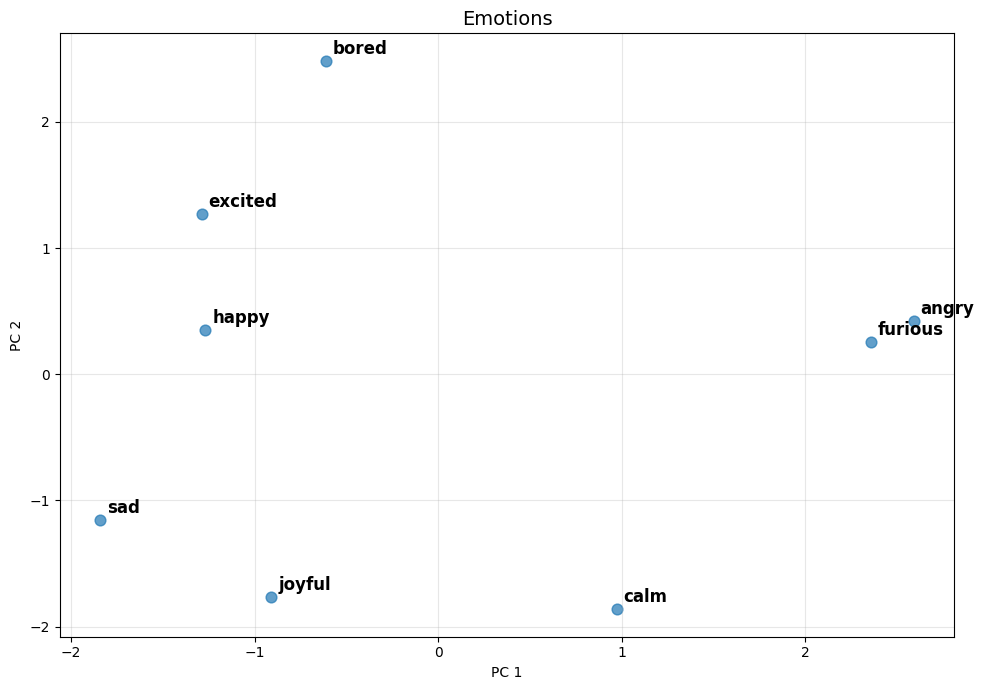

In [20]:
# Your custom word cluster visualization
my_words = ["happy", "sad", "angry", "joyful", "furious", "calm", "excited", "bored"]
plot_words(my_words, wv, title="Emotions")